In [2]:
import pandas as pd
import datetime

df = pd.read_csv("online_retail_II.csv", encoding="latin-1")
print(df.shape)

(541910, 8)


In [3]:
df_clean = df.dropna(subset=['Customer ID'])
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C')]
df_clean = df_clean.copy()
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']
print(df_clean.shape)

C:\Users\dehom\AppData\Local\Temp\ipykernel_1908\3980316685.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


(397885, 9)


In [4]:
reference_date = datetime.datetime(2011, 12, 10)

rfm = df_clean.groupby('Customer ID').agg(
    Recence=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequence=('Invoice', 'nunique'),
    Montant=('TotalPrice', 'sum')
).reset_index()

print(rfm.shape)
print(rfm.head())

(4338, 4)
   Customer ID  Recence  Frequence   Montant
0        12346      325          1  77183.60
1        12347        2          7   4310.00
2        12348       75          4   1797.24
3        12349       18          1   1757.55
4        12350      310          1    334.40


In [5]:
# Score Récence : inversé (petit = récent = bien)
rfm['Score_R'] = pd.qcut(rfm['Recence'], q=5, labels=[5, 4, 3, 2, 1])

# Score Fréquence
rfm['Score_F'] = pd.qcut(rfm['Frequence'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Score Montant
rfm['Score_M'] = pd.qcut(rfm['Montant'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Score total
rfm['Score_Total'] = rfm['Score_R'].astype(int) + rfm['Score_F'].astype(int) + rfm['Score_M'].astype(int)

print(rfm.head())

   Customer ID  Recence  Frequence   Montant Score_R Score_F Score_M  \
0        12346      325          1  77183.60       1       1       5   
1        12347        2          7   4310.00       5       5       5   
2        12348       75          4   1797.24       2       4       4   
3        12349       18          1   1757.55       4       1       4   
4        12350      310          1    334.40       1       1       2   

   Score_Total  
0            7  
1           15  
2           10  
3            9  
4            4  


In [6]:
def segment_client(score):
    if score >= 13:
        return 'Champion'
    elif score >= 10:
        return 'Fidèle'
    elif score >= 7:
        return 'À risque'
    else:
        return 'Perdu'

rfm['Segment'] = rfm['Score_Total'].apply(segment_client)

print(rfm['Segment'].value_counts())
print(rfm.head(10))

Segment
Perdu       1307
À risque    1092
Fidèle      1007
Champion     932
Name: count, dtype: int64
   Customer ID  Recence  Frequence   Montant Score_R Score_F Score_M  \
0        12346      325          1  77183.60       1       1       5   
1        12347        2          7   4310.00       5       5       5   
2        12348       75          4   1797.24       2       4       4   
3        12349       18          1   1757.55       4       1       4   
4        12350      310          1    334.40       1       1       2   
5        12352       36          8   2506.04       3       5       5   
6        12353      204          1     89.00       1       1       1   
7        12354      232          1   1079.40       1       1       4   
8        12355      214          1    459.40       1       1       2   
9        12356       22          3   2811.43       4       3       5   

   Score_Total   Segment  
0            7  À risque  
1           15  Champion  
2           10    Fidèle

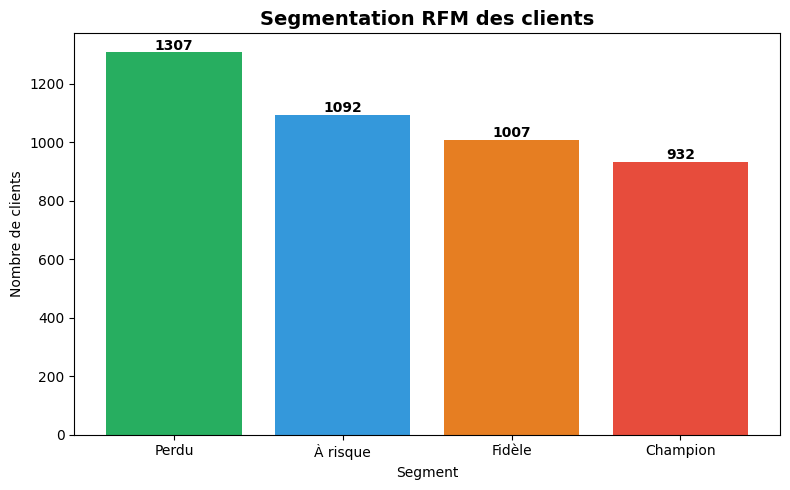

Graphique sauvegardé


In [7]:
import matplotlib.pyplot as plt

# Répartition des segments
segment_counts = rfm['Segment'].value_counts()

colors = ['#27AE60', '#3498DB', '#E67E22', '#E74C3C']

plt.figure(figsize=(8, 5))
bars = plt.bar(segment_counts.index, segment_counts.values, color=colors)
plt.title('Segmentation RFM des clients', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Nombre de clients')

for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('segmentation_rfm.png', dpi=150)
plt.show()
print("Graphique sauvegardé")

C:\Users\dehom\AppData\Local\Temp\ipykernel_1908\420257476.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.values, y=segment_counts.index, ax=axes[0, 1], palette='viridis')
C:\Users\dehom\AppData\Local\Temp\ipykernel_1908\420257476.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=montant_seg.values, y=montant_seg.index, ax=axes[1, 0], palette='magma')


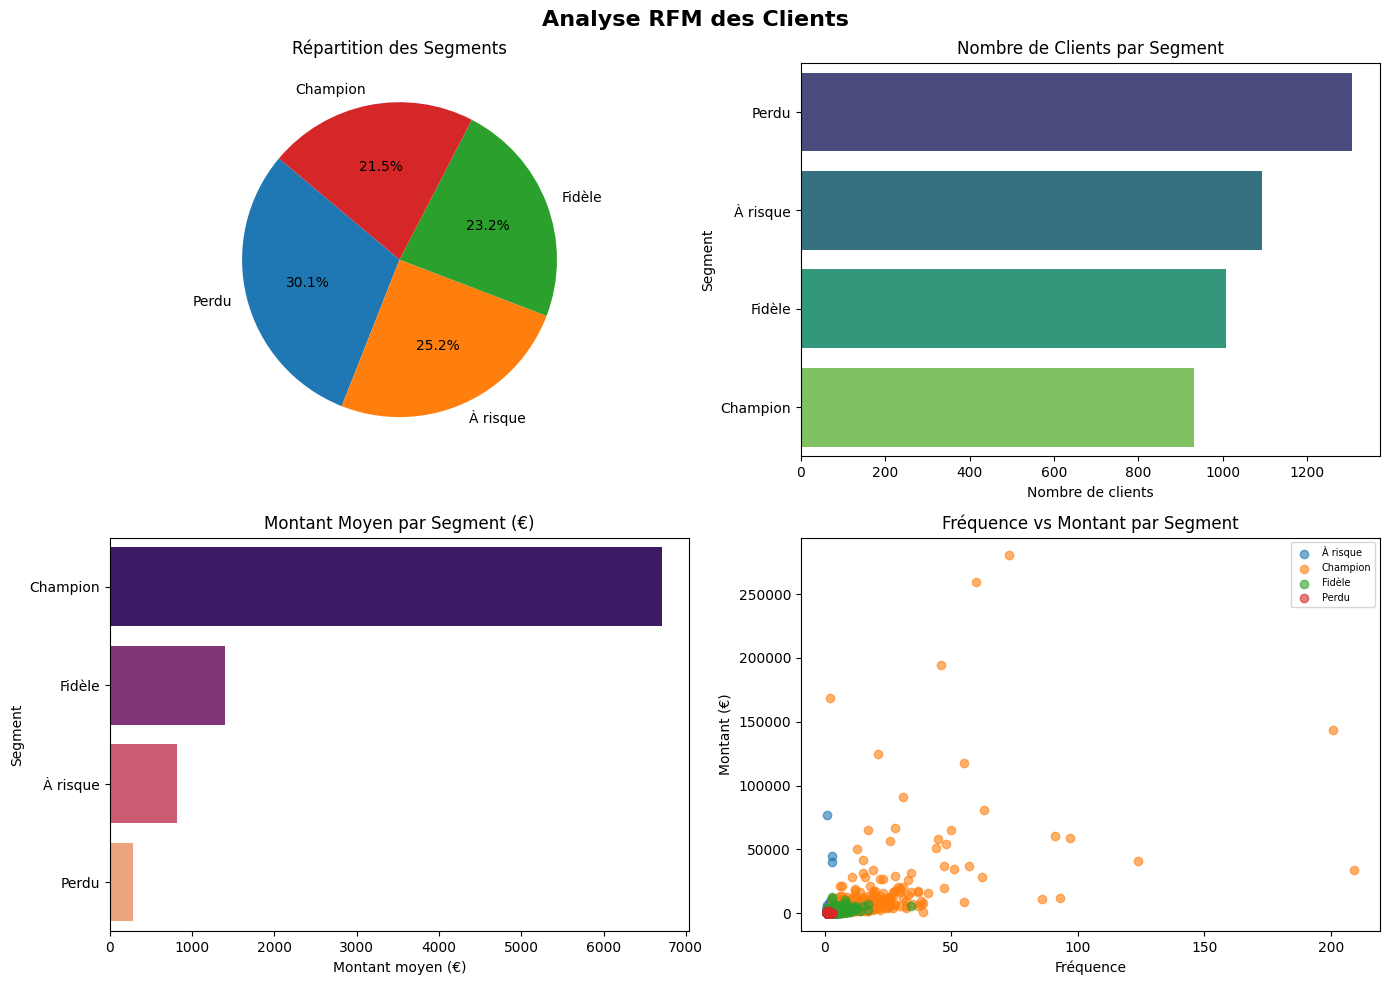

Graphique sauvegardé


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse RFM des Clients', fontsize=16, fontweight='bold')

# 1. Répartition des segments (camembert)
segment_counts = rfm['Segment'].value_counts()
axes[0, 0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140)
axes[0, 0].set_title('Répartition des Segments')

# 2. Nombre de clients par segment (barplot)
sns.barplot(x=segment_counts.values, y=segment_counts.index, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Nombre de Clients par Segment')
axes[0, 1].set_xlabel('Nombre de clients')

# 3. Montant moyen par segment
montant_seg = rfm.groupby('Segment')['Montant'].mean().sort_values(ascending=False)
sns.barplot(x=montant_seg.values, y=montant_seg.index, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Montant Moyen par Segment (€)')
axes[1, 0].set_xlabel('Montant moyen (€)')

# 4. Scatter plot Fréquence vs Montant coloré par segment
segments_uniques = rfm['Segment'].unique()
couleurs = plt.cm.tab10.colors
for i, seg in enumerate(segments_uniques):
    subset = rfm[rfm['Segment'] == seg]
    axes[1, 1].scatter(subset['Frequence'], subset['Montant'],
                       label=seg, alpha=0.6, color=couleurs[i % len(couleurs)])
axes[1, 1].set_title('Fréquence vs Montant par Segment')
axes[1, 1].set_xlabel('Fréquence')
axes[1, 1].set_ylabel('Montant (€)')
axes[1, 1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('analyse_rfm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé")

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Définir la variable cible
rfm['Churn'] = (rfm['Segment'] == 'Perdu').astype(int)

# Features et target
X = rfm[['Recence', 'Frequence', 'Montant']]
y = rfm['Churn']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape[0]} lignes")
print(f"Test : {X_test.shape[0]} lignes")
print(f"Taux de churn : {y.mean()*100:.1f}%")

Train : 3470 lignes
Test : 868 lignes
Taux de churn : 30.1%


In [10]:
# Entraînement
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Résultats
print("=== PERFORMANCE DU MODÈLE ===")
print(classification_report(y_test, y_pred, target_names=['Non churné', 'Churné']))

# Importance des features
importances = pd.DataFrame({
    'Feature': ['Recence', 'Frequence', 'Montant'],
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== IMPORTANCE DES VARIABLES ===")
print(importances)

=== PERFORMANCE DU MODÈLE ===
              precision    recall  f1-score   support

  Non churné       0.97      0.98      0.97       610
      Churné       0.95      0.93      0.94       258

    accuracy                           0.96       868
   macro avg       0.96      0.95      0.96       868
weighted avg       0.96      0.96      0.96       868


=== IMPORTANCE DES VARIABLES ===
     Feature  Importance
0    Recence    0.357481
2    Montant    0.337277
1  Frequence    0.305242


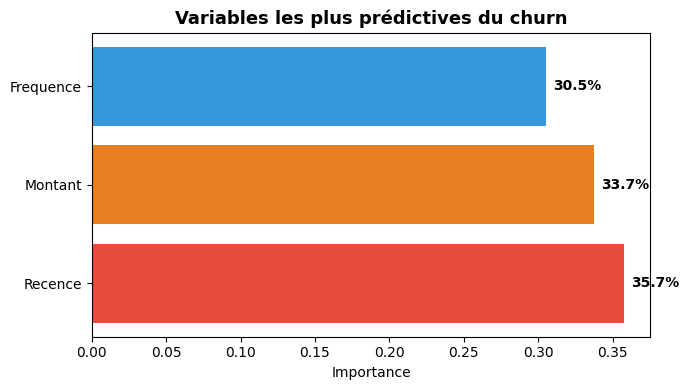

Graphique sauvegardé


In [11]:
plt.figure(figsize=(7, 4))
bars = plt.barh(importances['Feature'], importances['Importance'], 
                color=['#E74C3C', '#E67E22', '#3498DB'])
plt.title('Variables les plus prédictives du churn', fontsize=13, fontweight='bold')
plt.xlabel('Importance')

for bar, val in zip(bars, importances['Importance']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('importance_variables.png', dpi=150)
plt.show()
print("Graphique sauvegardé")

In [12]:
import sqlite3

# Créer une base de données SQLite en mémoire
conn = sqlite3.connect('retailsense.db')

# Charger les données nettoyées dans SQLite
df_clean.to_sql('transactions', conn, if_exists='replace', index=False)
rfm.to_sql('clients_rfm', conn, if_exists='replace', index=False)

print("Base de données créée avec succès")
print("Tables disponibles :")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

Base de données créée avec succès
Tables disponibles :
           name
0  transactions
1   clients_rfm


In [13]:
# Requête 1 : Chiffre d'affaires par pays (Top 10)
query1 = """
SELECT Country, 
       ROUND(SUM(TotalPrice), 2) as CA_Total,
       COUNT(DISTINCT "Customer ID") as Nb_Clients
FROM transactions
GROUP BY Country
ORDER BY CA_Total DESC
LIMIT 10
"""
top_pays = pd.read_sql(query1, conn)
print("=== TOP 10 PAYS PAR CA ===")
print(top_pays)

# Requête 2 : Répartition des segments churn
query2 = """
SELECT Segment,
       COUNT(*) as Nb_Clients,
       ROUND(AVG(Montant), 2) as Montant_Moyen,
       ROUND(AVG(Recence), 1) as Recence_Moyenne
FROM clients_rfm
GROUP BY Segment
ORDER BY Nb_Clients DESC
"""
segments = pd.read_sql(query2, conn)
print("\n=== ANALYSE PAR SEGMENT ===")
print(segments)

# Requête 3 : Clients à risque avec fort potentiel
query3 = """
SELECT "Customer ID", Recence, Frequence, ROUND(Montant, 2) as Montant, Segment
FROM clients_rfm
WHERE Segment = 'À risque'
AND Montant > 1000
ORDER BY Montant DESC
LIMIT 10
"""
risque_fort = pd.read_sql(query3, conn)
print("\n=== CLIENTS À RISQUE HAUTE VALEUR ===")
print(risque_fort)

=== TOP 10 PAYS PAR CA ===
          Country    CA_Total  Nb_Clients
0  United Kingdom  7308391.55        3920
1     Netherlands   285446.34           9
2            EIRE   265545.90           3
3         Germany   228867.14          94
4          France   209042.05          87
5       Australia   138521.31           9
6           Spain    61577.11          30
7     Switzerland    56443.95          21
8         Belgium    41196.34          25
9          Sweden    38378.33           8

=== ANALYSE PAR SEGMENT ===
    Segment  Nb_Clients  Montant_Moyen  Recence_Moyenne
0     Perdu        1307         279.64            191.4
1  À risque        1092         815.77             85.1
2    Fidèle        1007        1396.21             42.9
3  Champion         932        6705.07             14.1

=== CLIENTS À RISQUE HAUTE VALEUR ===
   Customer ID  Recence  Frequence   Montant   Segment
0        12346      325          1  77183.60  À risque
1        15749      235          3  44534.30  À risqu

In [14]:
# Sauvegarder les fichiers pour GitHub et Power BI
rfm.to_csv('rfm_clients.csv', index=False)
top_pays.to_csv('top_pays.csv', index=False)
segments.to_csv('segments.csv', index=False)
risque_fort.to_csv('clients_risque_haute_valeur.csv', index=False)

conn.close()

print("Fichiers sauvegardés :")
print("- rfm_clients.csv")
print("- top_pays.csv")
print("- segments.csv")
print("- clients_risque_haute_valeur.csv")

Fichiers sauvegardés :
- rfm_clients.csv
- top_pays.csv
- segments.csv
- clients_risque_haute_valeur.csv
